# Laboratorio 4 — Análisis Exploratorio de Datos (EDA)

**Asignatura:** Analítica de Datos  
**Caso:** Andina Retail

## Objetivo

Explorar el comportamiento de las transacciones de Andina Retail mediante estadística descriptiva, agrupaciones y visualizaciones.

En este laboratorio buscaremos responder:

1. ¿Cuál es el valor típico de una transacción?
2. ¿Cómo cambia el valor vendido entre ciudades y categorías?
3. ¿Cómo se distribuye el valor de las transacciones?
4. ¿Existen transacciones potencialmente atípicas?
5. ¿Qué conclusiones podemos formular a partir de la evidencia?

> Cada cálculo y cada gráfico debe responder una pregunta analítica.

## 1. Carga de los datos preparados

En los laboratorios anteriores inspeccionamos, evaluamos y preparamos el dataset.

Ahora utilizaremos `ventas_preparadas.csv`, generado al finalizar el Laboratorio 3.

Antes de comenzar el análisis verificaremos que el archivo fue cargado correctamente.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/content/ventas_preparadas.csv",
    parse_dates=["fecha"]
)

df.head()

,fecha,id_cliente,producto,categoria,ciudad,unidades,precio_unitario,descuento,canal,ventas
0,2025-11-03,13375,Guantes gym,Deportes,Bogota,4,48100.0,0.05,En linea,182780.0
1,2025-06-05,19441,Licuadora,Hogar,Barranquilla,5,81800.0,0.00,Tienda,409000.0
2,2025-06-02,10603,Tapete yoga,Deportes,Bogota,2,75200.0,0.10,En linea,135360.0
3,2025-11-15,10698,Bicicleta estatica,Deportes,Bogota,3,42300.0,0.00,Tienda,126900.0
4,2025-08-29,15539,Tenis urbanos,Moda,Cali,1,94500.0,0.05,Tienda,89775.0


In [ ]:
df.shape

(4820, 10)

### Verificación

El dataset debe conservar:

- 4.820 transacciones;
- 10 variables;
- las transformaciones realizadas durante la preparación.

A partir de este punto comenzaremos el análisis exploratorio.

## 2. ¿Cuál es el valor típico de una transacción?

La variable `ventas` representa el **valor monetario final de cada transacción**.

Comenzaremos examinando su resumen estadístico.

In [ ]:
df["ventas"].describe()

,ventas
count,4.820000e+03
mean,2.729685e+05
std,3.771759e+05
min,1.220000e+04
25%,9.035000e+04
50%,1.662250e+05
75%,3.118200e+05
max,1.245000e+07


### Actividad de análisis

A partir del resumen estadístico obtenido para la variable **`ventas`**, responda:

1. ¿Cuántas transacciones tienen información disponible según el valor de `count`?

2. ¿Cuál es el valor promedio de las ventas?

3. ¿Cuál es la mediana de las ventas?

4. ¿Cuál es el valor mínimo y cuál es el valor máximo registrado?

5. ¿Qué indican los valores correspondientes al primer cuartil (`25%`) y al tercer cuartil (`75%`)?

6. Compare la **media** y la **mediana**. ¿Cuál es mayor?

7. ¿Qué podría indicar la diferencia entre la media y la mediana sobre la distribución de las ventas?

8. Observe la desviación estándar (`std`). ¿Qué información proporciona este valor sobre la variabilidad de las ventas?

---

**A continuación, calcule la media y la mediana de la variable `ventas` para comparar ambas medidas.**

In [ ]:
media_ventas = df["ventas"].mean()
mediana_ventas = df["ventas"].median()
desviacion_ventas = df["ventas"].std()
print("Media:", media_ventas)
print("Mediana:", mediana_ventas)
print("Desviación estándar:", desviacion_ventas)

Media: 272968.53319502075
Mediana: 166225.0
Desviación estándar: 377175.86208496586


## 3. ¿Cómo cambia el valor vendido entre ciudades?

Una medida global puede ocultar diferencias entre grupos.

Agruparemos las transacciones por `ciudad` y calcularemos:

- `count`: número de transacciones;
- `mean`: valor promedio de una transacción;
- `sum`: valor monetario total vendido.

In [ ]:
ventas_ciudad = (
    df.groupby("ciudad")["ventas"]
      .agg(["count", "mean", "sum"])
      .sort_values("sum", ascending=False)
)
ventas_ciudad

,count,mean,sum
ciudad,,,
Medellin,1489,273731.346541,407585975.0
Bogota,1351,263968.527017,356621480.0
Cali,1080,282836.379630,305463290.0
Barranquilla,900,273375.094444,246037585.0


### Interprete

A partir de los resultados obtenidos por ciudad, responda:

1. ¿Qué ciudad registra el mayor valor total vendido?

2. ¿Qué ciudad presenta el mayor número de transacciones?

3. ¿Qué ciudad presenta el mayor valor promedio por transacción?

4. ¿La ciudad con más transacciones es necesariamente la que registra el mayor valor total vendido? Justifique su respuesta.

### Recuerde

- `count` → número de transacciones.
- `mean` → valor promedio de una transacción.
- `sum` → valor monetario total vendido.

**Estos indicadores representan conceptos diferentes y no deben interpretarse como equivalentes.**

## 4. ¿Cómo cambia el valor vendido entre categorías?

Ahora realizaremos el mismo análisis utilizando la categoría del producto.

Esto permitirá determinar si las categorías presentan diferencias en número de transacciones, valor promedio y valor total vendido.

In [ ]:
ventas_categoria = (
    df.groupby("categoria")["ventas"]
      .agg(["count", "mean", "sum"])
      .sort_values("sum", ascending=False)
)

ventas_categoria

,count,mean,sum
categoria,,,
Tecnologia,813,750649.557196,610278090.0
Hogar,1543,220752.495139,340621100.0
Moda,1484,159335.053908,236453220.0
Deportes,980,130975.428571,128355920.0


### Interprete

A partir de los resultados obtenidos por categoría, responda:

1. ¿Qué categoría registra el mayor valor total vendido?

2. ¿Qué categoría presenta el mayor número de transacciones?

3. ¿Qué categoría presenta el mayor valor promedio por transacción?

4. ¿La categoría con mayor número de transacciones es también la que genera mayores ventas totales? Justifique su respuesta.

5. Compare las categorías **Tecnología** y **Hogar**. ¿Qué puede concluir sobre la relación entre el número de transacciones, el valor promedio por transacción y las ventas totales?

### Recuerde

- `count` → indica la cantidad de transacciones.
- `mean` → indica el valor promedio de cada transacción.
- `sum` → indica el valor monetario total vendido.

**Una mayor cantidad de transacciones no implica necesariamente un mayor valor total vendido.**

## 5. ¿Cómo se distribuye el valor de las transacciones?

Los estadísticos descriptivos resumen los datos mediante números.

Ahora utilizaremos un histograma para observar la forma de la distribución de `ventas`.

Un histograma agrupa los valores en intervalos y muestra cuántas observaciones aparecen en cada uno.

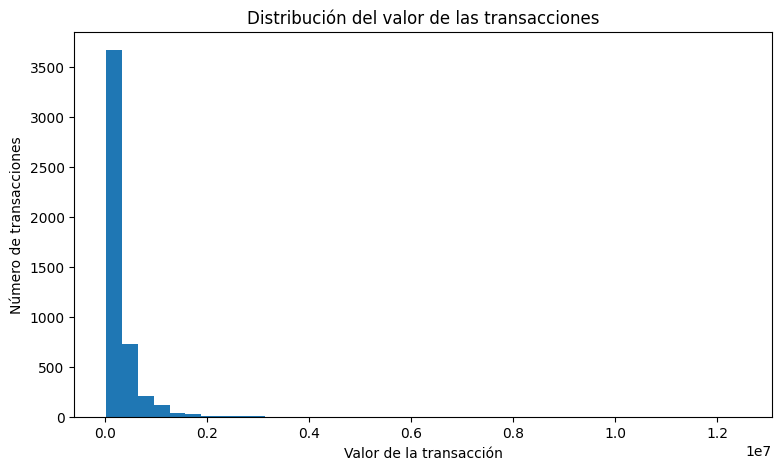

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(
    df["ventas"],
    bins=40
)
plt.xlabel("Valor de la transacción")
plt.ylabel("Número de transacciones")
plt.title("Distribución del valor de las transacciones")
plt.show()

### Interprete

Observe la forma del histograma y responda:

1. ¿Dónde se concentra la mayoría de las transacciones?

2. ¿La distribución parece simétrica? Justifique su respuesta a partir del histograma.

3. ¿Se observa una cola hacia valores elevados? ¿Hacia qué lado de la distribución?

4. ¿Existen pocas transacciones con valores considerablemente superiores al resto?

5. Compare la forma del histograma con los valores de la **media** y la **mediana** obtenidos anteriormente. ¿La forma de la distribución ayuda a explicar la diferencia entre ambas medidas? Justifique.

6. De acuerdo con la forma observada, ¿cómo describiría la distribución de la variable `ventas`?

7. ¿Considera que la media representa adecuadamente el valor de una transacción típica? Explique su respuesta.

## 6. ¿Dónde se concentra el valor vendido?

Ya obtuvimos esta información mediante `groupby()`.

Ahora representaremos el valor total vendido por ciudad mediante un gráfico de barras para facilitar su comparación visual.

In [ ]:
ventas_por_ciudad = (
    df.groupby("ciudad")["ventas"]
      .sum()
      .sort_values(ascending=False)
)

ventas_por_ciudad

,ventas
ciudad,
Medellin,407585975.0
Bogota,356621480.0
Cali,305463290.0
Barranquilla,246037585.0


### Interprete

A partir del resultado obtenido, responda:

1. ¿Qué ciudad concentra el mayor valor total vendido?

2. ¿Qué ciudad registra el menor valor total vendido?

3. ¿Cuál es el orden de las ciudades de mayor a menor valor total vendido?

### ¿Qué hicimos?

Analice las operaciones utilizadas en el código y responda:

- ¿Qué función cumple `groupby("ciudad")`?
- ¿Por qué se selecciona la variable `["ventas"]`?
- ¿Qué operación realiza `.sum()`?
- ¿Qué efecto tiene `.sort_values(ascending=False)` sobre los resultados?

### Reflexione

¿Los valores obtenidos representan el **número de transacciones**, el **valor promedio por transacción** o las **ventas totales** de cada ciudad? Justifique su respuesta.

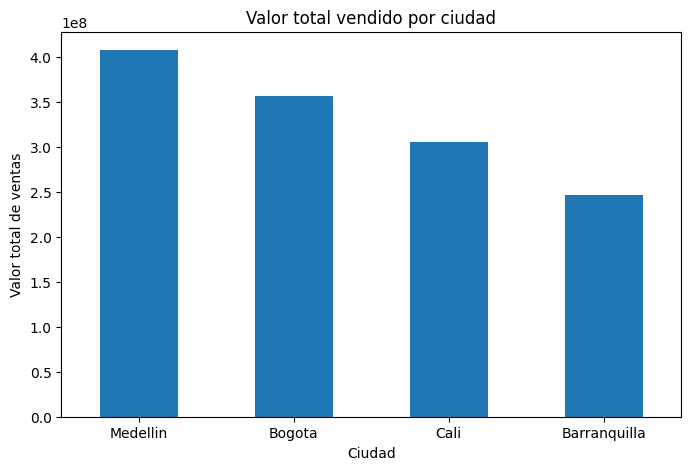

In [ ]:
plt.figure(figsize=(8, 5))
ventas_por_ciudad.plot(kind="bar")
plt.xlabel("Ciudad")
plt.ylabel("Valor total de ventas")
plt.title("Valor total vendido por ciudad")
plt.xticks(rotation=0)
plt.show()

### Interprete

A partir del gráfico obtenido, responda:

1. ¿Qué ciudad presenta el mayor valor total vendido?

2. ¿Qué ciudad presenta el menor valor total vendido?

3. ¿Las diferencias en el valor total vendido entre las ciudades parecen grandes o pequeñas? Justifique su respuesta a partir del gráfico.

4. ¿Qué patrón observa al comparar visualmente las ventas totales de las diferentes ciudades?

### Reflexione

1. ¿El gráfico reemplaza los cálculos realizados previamente mediante `groupby()`? Explique.

2. ¿Qué variable está representando el gráfico?

3. ¿Es posible determinar únicamente con este gráfico qué ciudad tiene el mayor número de transacciones? ¿Por qué?

4. ¿Es posible determinar únicamente con este gráfico qué ciudad tiene el mayor valor promedio por transacción? Justifique.

## 7. ¿Cómo se distribuye el valor vendido entre categorías?

Realizaremos ahora la misma comparación utilizando las categorías de producto.

In [ ]:
ventas_por_categoria = (
    df.groupby("categoria")["ventas"]
      .sum()
      .sort_values(ascending=False)
)
ventas_por_categoria

,ventas
categoria,
Tecnologia,610278090.0
Hogar,340621100.0
Moda,236453220.0
Deportes,128355920.0


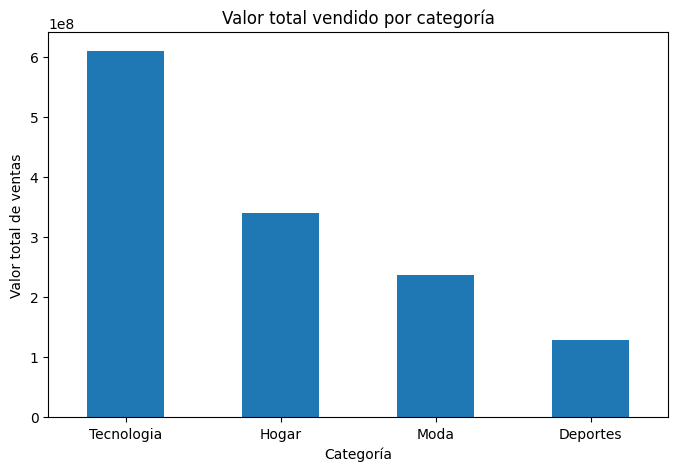

In [ ]:
plt.figure(figsize=(8, 5))

ventas_por_categoria.plot(kind="bar")

plt.xlabel("Categoría")
plt.ylabel("Valor total de ventas")
plt.title("Valor total vendido por categoría")
plt.xticks(rotation=0)

plt.show()

### Interprete

A partir del gráfico obtenido, responda:

1. ¿Qué ciudad presenta el mayor valor total vendido?

2. ¿Qué ciudad presenta el menor valor total vendido?

3. ¿Las diferencias entre ciudades parecen grandes o pequeñas? Justifique su respuesta a partir de lo observado en el gráfico.

4. ¿Cuál es el orden de las ciudades de mayor a menor valor total vendido?

### Importante

El gráfico **no reemplaza el cálculo**. Su función es facilitar la comparación visual de los resultados obtenidos previamente mediante `groupby()`.

Además, este gráfico representa el **valor total vendido por ciudad**. No permite determinar por sí solo cuál ciudad tiene más transacciones ni cuál presenta el mayor valor promedio por transacción.

## 8. ¿Existen transacciones potencialmente atípicas?

Durante el Laboratorio 2 encontramos valores que parecían alejados del comportamiento habitual.

Utilizaremos un **boxplot** para observar la distribución de `ventas` e identificar visualmente observaciones alejadas del resto.

Un punto alejado de los bigotes puede considerarse estadísticamente inusual, pero esto **no significa automáticamente que sea un error**.

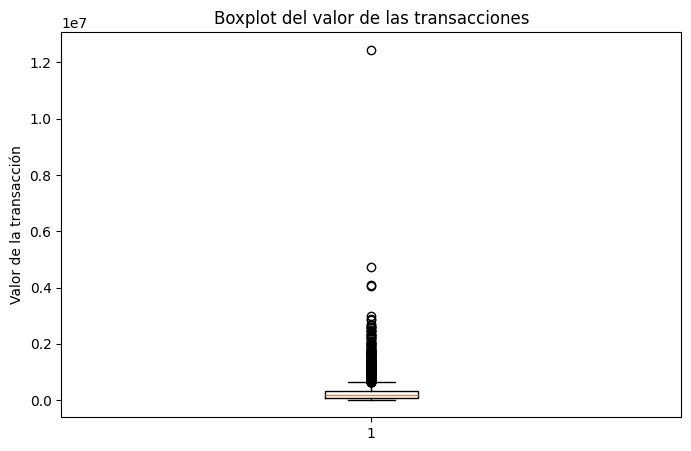

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["ventas"])
plt.ylabel("Valor de la transacción")
plt.title("Boxplot del valor de las transacciones")
plt.show()

### Interprete

A partir del boxplot obtenido, responda:

1. ¿Se observan transacciones potencialmente atípicas?

2. ¿Los valores atípicos aparecen principalmente por encima o por debajo de la distribución?

3. ¿Cuál es aproximadamente el valor más extremo observado?

4. ¿Podemos concluir únicamente a partir del boxplot que estas observaciones corresponden a errores? Justifique su respuesta.

5. ¿Deberíamos eliminar inmediatamente las observaciones identificadas como potencialmente atípicas? ¿Por qué?

### Reflexione

¿Cuál es la diferencia entre un **valor atípico** y un **valor incorrecto**?

¿Qué información adicional necesitaría para decidir si una observación atípica debe mantenerse, corregirse o eliminarse del dataset?

## 9. ¿Qué transacciones presentan los valores más altos?

El boxplot nos indica que pueden existir observaciones inusuales.

Ahora examinaremos directamente las cinco transacciones con mayor valor monetario.

In [ ]:
columnas = [
    "fecha",
    "id_cliente",
    "producto",
    "categoria",
    "ciudad",
    "unidades",
    "precio_unitario",
    "descuento",
    "ventas"
]
df.nlargest(5, "ventas")[columnas]

,fecha,id_cliente,producto,categoria,ciudad,unidades,precio_unitario,descuento,ventas
1700,2025-12-25,14901,Portatil 14,Tecnologia,Medellin,500,3200000.0,0.0,12450000.0
4391,2025-04-27,15041,Monitor 24,Tecnologia,Bogota,3,1574600.0,0.0,4723800.0
630,2025-11-09,11063,Audifonos BT,Tecnologia,Cali,3,1367800.0,0.0,4103400.0
3075,2025-06-14,15654,Audifonos BT,Tecnologia,Cali,3,1683300.0,0.2,4039920.0
45,2025-03-10,13351,Audifonos BT,Tecnologia,Medellin,3,1102700.0,0.1,2977290.0


### Interprete

Examine las cinco transacciones con mayor valor monetario y responda:

1. ¿Cuál es la transacción de mayor valor?

2. ¿Qué característica diferencia esta transacción de las demás transacciones de alto valor?

3. ¿El elevado valor de la transacción se explica únicamente por un precio unitario alto? Justifique su respuesta.

4. ¿Podemos afirmar, únicamente con la información disponible, que la cantidad registrada corresponde a un error? ¿Por qué?

5. ¿Qué debería hacerse antes de eliminar o modificar este registro?

### Reflexione

A partir del análisis realizado, responda:

- ¿Por qué no es suficiente identificar un valor atípico únicamente mediante una técnica estadística?
- ¿Qué otras variables del registro deberían analizarse para comprender por qué la transacción presenta un valor tan elevado?
- ¿Qué papel cumple el contexto del problema al decidir si un valor atípico debe mantenerse, corregirse o eliminarse?

## 10. Retomemos un hallazgo anterior

Durante la evaluación de calidad encontramos una transacción con `500` unidades.

En ese momento decidimos no eliminarla porque no teníamos evidencia suficiente para afirmar que fuera incorrecta.

Ahora podemos examinarla dentro del contexto exploratorio.

In [ ]:
df.loc[df["unidades"] == df["unidades"].max()]

,fecha,id_cliente,producto,categoria,ciudad,unidades,precio_unitario,descuento,canal,ventas
1700,2025-12-25,14901,Portatil 14,Tecnologia,Medellin,500,3200000.0,0.0,Tienda,12450000.0


### Discusión

A partir de los resultados obtenidos, responda:

1. ¿La transacción analizada sigue pareciendo inusual frente al resto del conjunto? Justifique su respuesta.

2. ¿Que una observación sea inusual significa necesariamente que sea incorrecta? Explique.

3. ¿Qué información adicional necesitaría para determinar si la transacción corresponde a un error o a una operación real?

### Reflexione

¿Qué permite concluir el análisis exploratorio sobre una observación inusual?

¿Es suficiente el análisis estadístico para afirmar que un dato es incorrecto? Justifique su respuesta.

# 11. Conclusiones basadas en evidencia

Ahora debe transformar los resultados obtenidos durante el laboratorio en **conclusiones analíticas**.

Redacte entre **tres y cinco afirmaciones** sobre las transacciones de **Andina Retail**.

Cada afirmación debe estar respaldada por una **tabla, estadístico o gráfico** obtenido durante el laboratorio.

## Debe poder responder

A partir de los análisis realizados, considere las siguientes preguntas:

- ¿Cuál es el valor típico de una transacción?
- ¿Cómo se comportan la media y la mediana? ¿Qué puede interpretar de su comparación?
- ¿Qué ciudad concentra el mayor valor vendido?
- ¿Qué categoría concentra el mayor valor vendido?
- ¿Cómo se distribuye el valor de las transacciones?
- ¿Existen valores potencialmente atípicos? ¿Qué puede concluir sobre ellos?

## Estructura recomendada

Utilice la siguiente estructura para construir cada conclusión:

**Hallazgo → evidencia → interpretación**

Por ejemplo:

> Se observa ____________________. Esto se evidencia en ____________________. Por tanto, podemos interpretar que ____________________.

## Conclusiones

Redacte entre **tres y cinco conclusiones** utilizando los resultados obtenidos durante el laboratorio.

1. **Hallazgo:**  
   **Evidencia:**  
   **Interpretación:**

2. **Hallazgo:**  
   **Evidencia:**  
   **Interpretación:**

3. **Hallazgo:**  
   **Evidencia:**  
   **Interpretación:**

4. **Hallazgo:**  
   **Evidencia:**  
   **Interpretación:**

5. **Hallazgo:**  
   **Evidencia:**  
   **Interpretación:**

### Importante

No complete una conclusión utilizando información que no esté respaldada por los resultados obtenidos.

Una conclusión analítica debe estar sustentada en **evidencia observable en los datos** y debe diferenciar claramente entre lo que los resultados permiten afirmar y aquello que requeriría información adicional.

# 12. Límites del análisis

El análisis exploratorio también debe establecer qué conclusiones **no están respaldadas por los datos**.

Con el análisis realizado podemos describir:

- distribuciones;
- diferencias entre grupos;
- valores típicos;
- dispersión;
- concentraciones;
- observaciones inusuales.

Sin embargo, con estos resultados por sí solos **no podemos afirmar causalidad**.

Por ejemplo, observar que una ciudad presenta mayor valor vendido que otra no demuestra por qué ocurre esa diferencia.

Tampoco hemos demostrado en este laboratorio que exista una **caída de las ventas**.

Para realizar afirmaciones de ese tipo necesitaríamos formular y realizar análisis adicionales.

## Interprete

A partir de los análisis realizados, responda:

1. ¿Podemos afirmar que Medellín vende más porque tiene mejores clientes? Justifique su respuesta.

2. ¿Podemos afirmar que pertenecer a la categoría Tecnología causa ventas más altas? ¿Por qué?

3. ¿Podemos afirmar que las ventas están disminuyendo? ¿Qué análisis adicional sería necesario para responder esta pregunta?

4. ¿Podemos afirmar que la transacción de 500 unidades corresponde a un error? Justifique su respuesta.

5. ¿Qué afirmaciones sí podemos realizar con la evidencia obtenida durante el laboratorio?

## Reflexione

¿Cuál es la diferencia entre **observar una asociación** en los datos y **demostrar una relación causal**?

¿De qué manera un patrón encontrado durante el EDA puede convertirse en una nueva pregunta o hipótesis para análisis posteriores?

# 13. Cierre del Laboratorio 4

Durante este laboratorio:

- calculamos medidas de tendencia central y dispersión;
- comparamos transacciones entre ciudades y categorías;
- utilizamos `groupby()` y `agg()` para resumir información;
- analizamos la distribución del valor de las transacciones;
- construimos histogramas y gráficos de barras;
- utilizamos un boxplot para identificar observaciones potencialmente atípicas;
- inspeccionamos las transacciones de mayor valor;
- formulamos conclusiones basadas en evidencia.

## Principales resultados obtenidos

- La **media** del valor de las transacciones es aproximadamente **$272.968,50**, mientras que la **mediana** es **$166.225**. La diferencia entre ambas medidas está relacionada con la presencia de transacciones de valores elevados.

- **Medellín** registra el mayor valor total vendido, con **$407.585.975**, y también el mayor número de transacciones, con **1.489**. Sin embargo, **Cali** presenta el mayor valor promedio por transacción, con aproximadamente **$282.836,38**.

- **Tecnología** es la categoría con mayor valor total vendido, con aproximadamente **$610.278.090**, mientras que **Hogar** presenta el mayor número de transacciones, con **1.543**. Esto evidencia que una mayor cantidad de transacciones no implica necesariamente un mayor valor total vendido.

- El histograma muestra una distribución **asimétrica hacia la derecha**: la mayoría de las transacciones se concentra en valores relativamente bajos y existe una cola hacia valores elevados.

- El boxplot permitió identificar varias observaciones **potencialmente atípicas**. Entre ellas destaca una transacción de **$12.450.000 asociada a 500 unidades**.

- La transacción de 500 unidades es claramente inusual frente al comportamiento general del conjunto, pero con la información disponible **no podemos afirmar que sea incorrecta**. Sería necesario investigar su origen y contexto.

## Idea central

El Análisis Exploratorio de Datos no consiste en producir tablas y gráficos.

Consiste en utilizarlos para:

**preguntar → observar → comparar → interpretar → concluir**

Los resultados obtenidos también muestran que una misma variable puede requerir diferentes formas de análisis. Por ejemplo, para comprender las ventas utilizamos medidas de tendencia central, agrupaciones, histogramas y boxplots, y cada herramienta permitió responder una pregunta diferente.

---

## De los datos a la analítica

A lo largo de los cuatro laboratorios seguimos una secuencia:

**Laboratorio 1**  
¿Qué datos tenemos?

↓

**Laboratorio 2**  
¿Qué problemas presentan?

↓

**Laboratorio 3**  
¿Cómo debemos prepararlos?

↓

**Laboratorio 4**  
¿Qué nos dicen los datos?

### Ejecutar código no equivale a realizar analítica de datos.

La analítica comienza cuando somos capaces de transformar los resultados del código en evidencia útil para comprender un problema y apoyar una decisión.

En estos laboratorios pasamos de **cargar e inspeccionar un conjunto de datos** a **evaluar su calidad, prepararlo, explorarlo e interpretar los resultados obtenidos**.

También aprendimos que debemos distinguir entre lo que los datos permiten observar y lo que realmente podemos concluir. Una diferencia, un patrón o un valor atípico puede generar nuevas preguntas, pero no demuestra por sí solo una relación causal.

---

## ¿Qué sigue?

El análisis realizado nos permitió estudiar variables individualmente y comparar grupos. Sin embargo, todavía quedan preguntas abiertas:

- ¿Cómo se relacionan unas variables con otras?
- ¿Existen patrones entre el descuento y el valor de las ventas?
- ¿El número de unidades está relacionado con el valor de la transacción?
- ¿Cómo podemos identificar formalmente valores atípicos?
- ¿Qué patrones aparecen cuando analizamos varias variables conjuntamente?

Estas preguntas serán el punto de partida para profundizar en el **Análisis Exploratorio de Datos (EDA)** y en la **detección de patrones iniciales**.